# Defense stocks after Russia's 2022 invasion of Ukraine

**Question.** After Russia's February 2022 invasion of Ukraine, did defense stocks become a better diversifier? Does the efficient portfolio allocate more to defense after the invasion than before, and does excluding defense (as many ESG funds do) cost investors more?

**Data.** `crsp_monthly_defense_sectors_2010_2025.xlsx`: CRSP Monthly Stock File (Version 2, CIZ) via WRDS, pulled by PERMNO, January 2010 – December 2025. This notebook builds on `Project1_new_data.ipynb` and leaves it unchanged. Run all cells from this folder to refresh the results.

**Universe (8 assets).** An equal-weighted defense basket (LMT, NOC, GD, LHX, rebalanced monthly) plus seven SPDR sector ETFs: XLE, XLF, XLI, XLK, XLP, XLU, XLV. The file also contains IGV and SOXX, but tech is represented by XLK so every sector is one comparable fund. XLI holds some defense names, which biases *against* finding a distinct role for defense.

**Event split.** Pre-invasion: January 2010 – February 2022. Post-invasion: March 2022 (first full month after the 24 February invasion) – December 2025.

**Method.** Same as `Project1_new_data.ipynb`: monthly total returns (including dividends); arithmetic mean × 12; sample covariance × 12; volatility = monthly sample standard deviation × √12. Portfolios are fully invested and long-only, with no risk-free asset. All figures are in-sample historical estimates, not forecasts.

**Selection criterion: global minimum variance (GMV).** The question is about diversification, and the GMV depends only on the covariance matrix. Covariances are estimated far more reliably than mean returns, especially in the 46-month post-invasion sample. Utility maximization (risk aversion = 4) is reported as a sensitivity check.

**Constraints: long-only, fully invested.** ESG funds and most investors cannot or do not short sector funds, and an exclusion question ("hold 0% defense") is only meaningful when weights cannot go negative.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from scipy.optimize import minimize
from IPython.display import display

INPUT_FILE = Path("crsp_monthly_defense_sectors_2010_2025.xlsx")
OUTPUT_DIR = Path("defense_results")
OUTPUT_DIR.mkdir(exist_ok=True)
ANNUALIZATION_FACTOR = 12
N_FRONTIER_POINTS = 101
DEFENSE_TICKERS = ["GD", "LHX", "LMT", "NOC"]
SECTOR_TICKERS = ["XLE", "XLF", "XLI", "XLK", "XLP", "XLU", "XLV"]
DEFENSE_LABEL = "DEF"
EVENT_MONTH = pd.Period("2022-03", freq="M")  # first full month after the 24 Feb 2022 invasion
RISK_AVERSION = 4
RISK_AVERSION_GRID = [2, 4, 6, 8, 10]
N_BOOTSTRAP = 500
RNG_SEED = 301
pd.set_option("display.max_columns", 20)

## 1. Load, identify securities, and audit

The file uses WRDS variable labels ("Monthly Total Return"); the equivalent CRSP codes (`MthRet`) are also accepted. `Monthly Total Return` is already a decimal monthly return including dividends. PERMNO identifies a continuous security history across ticker changes (HRS → LHX in 2019, IGW → SOXX in 2010), and each series is labelled with its latest ticker. Identical duplicate rows are removed; conflicting duplicates cause an error. Returns above 100% are flagged, not deleted.

In [2]:
raw = pd.read_excel(INPUT_FILE)
raw.columns = raw.columns.str.strip()
column_map = {"Monthly Calendar Date": "Date", "MthCalDt": "Date",
              "Monthly Total Return": "Return", "MthRet": "Return"}
df = raw.rename(columns=column_map)
required = {"PERMNO", "Date", "Ticker", "Return"}
if not required.issubset(df.columns):
    raise ValueError(f"Missing columns: {required - set(df.columns)}")
df = df[["PERMNO", "Date", "Ticker", "Return"]].copy()
if df[["PERMNO", "Date", "Ticker"]].isna().any().any():
    raise ValueError("Missing security identifiers, dates, or tickers")
df["Date"] = pd.to_datetime(df["Date"], errors="raise")
df["Ticker"] = df["Ticker"].astype(str).str.strip()
df["Return"] = pd.to_numeric(df["Return"], errors="raise")
if np.isinf(df["Return"].dropna()).any() or (df["Return"] < -1).any():
    raise ValueError("Invalid simple return (infinite or below -100%)")
df["Month"] = df["Date"].dt.to_period("M")
exact_duplicates = int(df.duplicated().sum())
df = df.drop_duplicates()
if df.duplicated(["PERMNO", "Month"]).any():
    raise ValueError("Multiple non-identical records for a security-month; inspect before proceeding")
labels = df.sort_values("Date").groupby("PERMNO")["Ticker"].last()
if labels.duplicated().any():
    raise ValueError("Latest ticker labels are not unique across securities")
identity = df.groupby(["PERMNO", "Ticker"]).agg(Start=("Month", "min"), End=("Month", "max"), Observations=("Return", "count")).reset_index()
identity["Analysis ticker"] = identity["PERMNO"].map(labels)
wide = df.pivot(index="Month", columns="PERMNO", values="Return").rename(columns=labels).sort_index()
wide = wide.reindex(pd.period_range(wide.index.min(), wide.index.max(), freq="M"))
wide.index.name = "Month"
wide.columns.name = "Ticker"
audit = pd.DataFrame({"Value": [len(raw), exact_duplicates, int(df["Return"].isna().sum()), int((df["Return"] > 1).sum()), len(wide), wide.shape[1]]},
                     index=["Raw rows", "Exact duplicates removed", "Missing returns", "Returns above 100% (retained)", "Calendar months", "Securities in file"])
display(audit, identity)

,Value
Raw rows,2504
Exact duplicates removed,8
Missing returns,0
Returns above 100% (retained),0
Calendar months,192
Securities in file,13


,PERMNO,Ticker,Start,End,Observations,Analysis ticker
0,12052,GD,2010-01,2025-12,192,GD
1,21178,LMT,2010-01,2025-12,192,LMT
2,24766,NOC,2010-01,2025-12,192,NOC
3,25582,HRS,2010-01,2019-06,114,LHX
4,25582,LHX,2019-07,2025-12,78,LHX
5,86451,XLV,2010-01,2025-12,192,XLV
6,86452,XLP,2010-01,2025-12,192,XLP
7,86454,XLE,2010-01,2025-12,192,XLE
8,86455,XLF,2010-01,2025-12,192,XLF
9,86456,XLI,2010-01,2025-12,192,XLI


## 2. Build the analysis universe and split at the invasion

The defense basket is the equal-weighted average of the four contractors' monthly returns, i.e. a portfolio rebalanced to equal weights each month. The analysis uses only months where every security in the universe has a return, and that common sample must have no gaps.

In [3]:
universe = DEFENSE_TICKERS + SECTOR_TICKERS
missing_tickers = set(universe) - set(wide.columns)
if missing_tickers:
    raise ValueError(f"Securities missing from the file: {sorted(missing_tickers)}")
complete = wide[universe].dropna(how="any")
if len(complete) < 24:
    raise ValueError("Fewer than 24 complete monthly observations")
if not complete.index.equals(pd.period_range(complete.index.min(), complete.index.max(), freq="M")):
    raise ValueError("Common sample has gaps; resolve before proceeding")

returns = complete[SECTOR_TICKERS].copy()
returns.insert(0, DEFENSE_LABEL, complete[DEFENSE_TICKERS].mean(axis=1))
periods = {"Full sample": returns,
           "Pre-invasion": returns[returns.index < EVENT_MONTH],
           "Post-invasion": returns[returns.index >= EVENT_MONTH]}
period_table = pd.DataFrame({name: {"Start": r.index.min(), "End": r.index.max(), "Months": len(r)} for name, r in periods.items()}).T
print(f"Excluded from the analysis (in file only): {sorted(set(wide.columns) - set(universe))}")
display(period_table)

Excluded from the analysis (in file only): ['IGV', 'SOXX']


,Start,End,Months
Full sample,2010-01,2025-12,192
Pre-invasion,2010-01,2022-02,146
Post-invasion,2022-03,2025-12,46


## 3. Asset metrics and correlations, before and after the invasion

The frontier uses annualized arithmetic means, not CAGR. Maximum drawdown is the worst decline from a preceding wealth peak (starting wealth 1). The key diversification evidence is defense's correlation with each sector before vs. after the invasion.

In [4]:
def estimate(r):
    return r.mean() * ANNUALIZATION_FACTOR, r.cov() * ANNUALIZATION_FACTOR

def performance(series):
    a = np.asarray(series, dtype=float)
    wealth = np.r_[1.0, np.cumprod(1 + a)]
    return {"CAGR": wealth[-1] ** (12 / len(a)) - 1,
            "Cumulative return": wealth[-1] - 1,
            "Max drawdown": np.min(wealth / np.maximum.accumulate(wealth) - 1)}

def asset_summary(r):
    mu, cov = estimate(r)
    table = pd.DataFrame({"Months": len(r), "Annualized mean": mu, "Annualized volatility": np.sqrt(np.diag(cov))}, index=r.columns)
    table = table.join(pd.DataFrame({t: performance(r[t]) for t in r.columns}).T)
    table["Worst month"] = r.min()
    table["Best month"] = r.max()
    return table

pct = lambda table: table.style.format({c: "{:.2%}" for c in table.columns if c != "Months"}).format({"Months": "{:.0f}"}, subset=[c for c in ["Months"] if c in table.columns])
summaries = {name: asset_summary(r) for name, r in periods.items()}
for name, table in summaries.items():
    print(name)
    display(pct(table))

correlations = {name: r.corr() for name, r in periods.items()}
print("Full-sample correlation matrix")
display(correlations["Full sample"].round(3))
defense_corr = pd.DataFrame({name: c[DEFENSE_LABEL].drop(DEFENSE_LABEL) for name, c in correlations.items()})
defense_corr.loc["Average across sectors"] = defense_corr.mean()
defense_corr["Change (post - pre)"] = defense_corr["Post-invasion"] - defense_corr["Pre-invasion"]
print("Defense basket correlation with each sector")
display(defense_corr.round(3))

Full sample


,Months,Annualized mean,Annualized volatility,CAGR,Cumulative return,Max drawdown,Worst month,Best month
Ticker,,,,,,,,
DEF,192,16.70%,17.73%,16.25%,1012.22%,-23.38%,-14.99%,19.93%
XLE,192,9.62%,26.46%,6.30%,165.65%,-63.91%,-34.27%,30.76%
XLF,192,13.23%,18.59%,12.12%,523.39%,-31.75%,-20.99%,16.85%
XLI,192,14.23%,17.62%,13.45%,653.58%,-27.13%,-18.60%,16.03%
XLK,192,18.83%,17.72%,18.71%,1456.28%,-31.22%,-11.97%,13.74%
XLP,192,10.15%,11.82%,9.87%,351.11%,-13.63%,-8.91%,10.45%
XLU,192,10.80%,14.07%,10.27%,377.54%,-18.83%,-11.29%,10.55%
XLV,192,12.71%,13.57%,12.45%,554.04%,-15.62%,-9.35%,12.59%


Pre-invasion


,Months,Annualized mean,Annualized volatility,CAGR,Cumulative return,Max drawdown,Worst month,Best month
Ticker,,,,,,,,
DEF,146,18.85%,18.10%,18.65%,700.75%,-23.38%,-14.99%,15.82%
XLE,146,8.59%,27.04%,5.04%,81.94%,-63.91%,-34.27%,30.76%
XLF,146,13.38%,18.59%,12.28%,309.41%,-31.75%,-20.99%,16.85%
XLI,146,14.05%,17.44%,13.28%,355.68%,-27.13%,-18.60%,16.03%
XLK,146,18.58%,16.23%,18.72%,707.04%,-17.37%,-8.66%,13.74%
XLP,146,11.94%,11.67%,11.86%,291.20%,-13.63%,-8.91%,10.45%
XLU,146,10.90%,13.29%,10.49%,236.58%,-18.83%,-9.95%,10.55%
XLV,146,14.42%,13.36%,14.41%,414.57%,-13.21%,-9.35%,12.59%


Post-invasion


,Months,Annualized mean,Annualized volatility,CAGR,Cumulative return,Max drawdown,Worst month,Best month
Ticker,,,,,,,,
DEF,46,9.88%,16.53%,8.95%,38.90%,-17.85%,-8.30%,19.93%
XLE,46,12.87%,24.79%,10.38%,46.01%,-17.12%,-17.12%,24.97%
XLF,46,12.75%,18.79%,11.59%,52.27%,-20.05%,-10.87%,11.92%
XLI,46,14.82%,18.36%,14.02%,65.38%,-18.83%,-10.44%,13.89%
XLK,46,19.61%,22.00%,18.69%,92.84%,-24.89%,-11.97%,13.45%
XLP,46,4.46%,12.27%,3.79%,15.31%,-12.86%,-8.14%,9.01%
XLU,46,10.49%,16.46%,9.55%,41.88%,-17.63%,-11.29%,10.34%
XLV,46,7.26%,14.25%,6.46%,27.10%,-15.62%,-6.26%,9.61%


Full-sample correlation matrix


Ticker,DEF,XLE,XLF,XLI,XLK,XLP,XLU,XLV
Ticker,,,,,,,,
DEF,1.000,0.490,0.615,0.708,0.446,0.496,0.288,0.520
XLE,0.490,1.000,0.702,0.673,0.448,0.418,0.215,0.461
XLF,0.615,0.702,1.000,0.870,0.642,0.560,0.299,0.630
XLI,0.708,0.673,0.870,1.000,0.745,0.659,0.411,0.669
XLK,0.446,0.448,0.642,0.745,1.000,0.527,0.331,0.553
XLP,0.496,0.418,0.560,0.659,0.527,1.000,0.626,0.685
XLU,0.288,0.215,0.299,0.411,0.331,0.626,1.000,0.410
XLV,0.520,0.461,0.630,0.669,0.553,0.685,0.410,1.000


Defense basket correlation with each sector


,Full sample,Pre-invasion,Post-invasion,Change (post - pre)
Ticker,,,,
XLE,0.490,0.501,0.461,-0.040
XLF,0.615,0.681,0.393,-0.287
XLI,0.708,0.761,0.542,-0.220
XLK,0.446,0.561,0.177,-0.384
XLP,0.496,0.519,0.412,-0.107
XLU,0.288,0.246,0.417,0.171
XLV,0.520,0.572,0.347,-0.224
Average across sectors,0.509,0.549,0.393,-0.156


## 4. Optimizers

For weights $w$, portfolio mean is $w^T\mu$ and variance is $w^T\Sigma w$. The GMV minimizes variance subject to $\sum_i w_i = 1$ and $0 \le w_i \le 1$. Frontier points add a target-return constraint. The utility-maximizing portfolio maximizes $w^T\mu - \frac{A}{2} w^T\Sigma w$ under the same constraints. Every solution is checked for convergence, weight constraints, and target accuracy, and the GMV is checked against the first-order optimality condition.

In [5]:
def _check(result, w, label):
    if not result.success:
        raise RuntimeError(f"Optimization failed ({label}): {result.message}")
    if abs(w.sum() - 1) > 1e-7 or w.min() < -1e-7 or w.max() > 1 + 1e-7:
        raise RuntimeError(f"Portfolio violates weight constraints ({label})")

def solve_min_variance(m, C, target=None):
    n = len(m)
    constraints = [{"type": "eq", "fun": lambda w: w.sum() - 1, "jac": lambda w: np.ones(n)}]
    w0 = np.ones(n) / n
    if target is not None:
        constraints.append({"type": "eq", "fun": lambda w: w @ m - target, "jac": lambda w: m})
        low, high = np.argmin(m), np.argmax(m)
        if m[high] > m[low]:
            frac = (target - m[low]) / (m[high] - m[low])
            w0 = np.zeros(n)
            w0[low], w0[high] = 1 - frac, frac
    result = minimize(lambda w: w @ C @ w, w0, jac=lambda w: 2 * C @ w,
                      bounds=[(0, 1)] * n, constraints=constraints, method="SLSQP",
                      options={"ftol": 1e-12, "maxiter": 2000})
    w = result.x
    _check(result, w, f"target={target}")
    if target is not None and abs(w @ m - target) > 1e-7:
        raise RuntimeError("Portfolio misses target return")
    if target is None:
        grad = 2 * C @ w
        if grad.min() - w @ grad < -1e-6:
            raise RuntimeError("GMV fails the first-order optimality check")
    return w

def solve_utility(m, C, risk_aversion):
    n = len(m)
    constraints = [{"type": "eq", "fun": lambda w: w.sum() - 1, "jac": lambda w: np.ones(n)}]
    result = minimize(lambda w: -(w @ m - risk_aversion / 2 * w @ C @ w), np.ones(n) / n,
                      jac=lambda w: -(m - risk_aversion * C @ w),
                      bounds=[(0, 1)] * n, constraints=constraints, method="SLSQP",
                      options={"ftol": 1e-12, "maxiter": 2000})
    _check(result, result.x, f"utility A={risk_aversion}")
    return result.x

def trace_frontier(m, C, assets, gmv_weights):
    gmv_return = gmv_weights @ m
    targets = np.unique(np.r_[np.linspace(m.min(), m.max(), N_FRONTIER_POINTS), gmv_return])
    rows = []
    for t in targets:
        w = solve_min_variance(m, C, float(t))
        rows.append({"Return": w @ m, "StdDev": np.sqrt(w @ C @ w), **dict(zip(assets, w))})
    frontier = pd.DataFrame(rows)
    frontier["Efficient"] = frontier["Return"] >= gmv_return - 1e-9
    return frontier

## 5. Optimize each period, with and without defense

"With defense" uses all 8 assets. "Without defense" drops the basket, as an ESG fund excluding weapons makers would. The chosen "most efficient" portfolio is the full-sample GMV with defense; the pre/post comparison answers the question.

In [6]:
results = {}
portfolio_rows = []
for period_name, r in periods.items():
    for universe_name, assets in {"With defense": list(r.columns), "Without defense": [c for c in r.columns if c != DEFENSE_LABEL]}.items():
        mu, cov = estimate(r[assets])
        m, C = mu.to_numpy(), cov.to_numpy()
        if np.linalg.eigvalsh(C).min() < -1e-10:
            raise ValueError("Covariance is not positive semidefinite")
        gmv_w = solve_min_variance(m, C)
        utility_w = solve_utility(m, C, RISK_AVERSION)
        frontier = trace_frontier(m, C, assets, gmv_w)
        if (frontier["StdDev"] < np.sqrt(gmv_w @ C @ gmv_w) - 1e-7).any():
            raise RuntimeError("A frontier point has lower risk than the GMV")
        results[(period_name, universe_name)] = {"assets": assets, "m": m, "C": C, "gmv": gmv_w, "utility": utility_w, "frontier": frontier}
        for criterion, w in {"GMV": gmv_w, f"Utility max (A={RISK_AVERSION})": utility_w}.items():
            row = {"Period": period_name, "Universe": universe_name, "Criterion": criterion,
                   "Annualized mean": w @ m, "Annualized volatility": np.sqrt(w @ C @ w)}
            row.update({a: w[i] for i, a in enumerate(assets)})
            portfolio_rows.append(row)

portfolios = pd.DataFrame(portfolio_rows).set_index(["Period", "Universe", "Criterion"])
portfolios = portfolios[["Annualized mean", "Annualized volatility", DEFENSE_LABEL] + SECTOR_TICKERS].fillna(0.0)
chosen_key = ("Full sample", "With defense")
chosen = results[chosen_key]
print("Chosen portfolio: full-sample GMV with defense")
print(f"  Expected return {chosen['gmv'] @ chosen['m']:.2%}, volatility {np.sqrt(chosen['gmv'] @ chosen['C'] @ chosen['gmv']):.2%}, weights sum to {chosen['gmv'].sum():.6f}")
display(portfolios.style.format("{:.2%}"))

Chosen portfolio: full-sample GMV with defense


  Expected return 11.81%, volatility 10.93%, weights sum to 1.000000


## 6. Does excluding defense cost more after the invasion?

Two measures of the cost of exclusion: (1) the increase in GMV volatility when defense is removed, and (2) the return given up at the same volatility, read off the efficient branches of the two frontiers where they overlap.

In [7]:
def efficient_branch(frontier):
    return frontier[frontier["Efficient"]].sort_values("StdDev")

cost_rows = []
for period_name in periods:
    with_def, without_def = results[(period_name, "With defense")], results[(period_name, "Without defense")]
    vol = lambda res: np.sqrt(res["gmv"] @ res["C"] @ res["gmv"])
    eff_with, eff_without = efficient_branch(with_def["frontier"]), efficient_branch(without_def["frontier"])
    low = max(eff_with["StdDev"].min(), eff_without["StdDev"].min())
    high = min(eff_with["StdDev"].max(), eff_without["StdDev"].max())
    grid = np.linspace(low, high, 50)
    gap = np.interp(grid, eff_with["StdDev"], eff_with["Return"]) - np.interp(grid, eff_without["StdDev"], eff_without["Return"])
    cost_rows.append({"Period": period_name,
                      "DEF weight in GMV": with_def["gmv"][0],
                      "GMV volatility with defense": vol(with_def),
                      "GMV volatility without defense": vol(without_def),
                      "Extra GMV volatility from excluding defense": vol(without_def) - vol(with_def),
                      "Average return lost at equal volatility": gap.mean(),
                      "Maximum return lost at equal volatility": gap.max()})
exclusion_cost = pd.DataFrame(cost_rows).set_index("Period")
display(exclusion_cost.style.format("{:.2%}"))

sensitivity = pd.DataFrame({period_name: {f"A = {a}": solve_utility(results[(period_name, "With defense")]["m"], results[(period_name, "With defense")]["C"], a)[0]
                                          for a in RISK_AVERSION_GRID}
                            for period_name in periods})
sensitivity.loc["GMV"] = [results[(p, "With defense")]["gmv"][0] for p in periods]
print("Defense basket weight by selection criterion")
display(sensitivity.style.format("{:.2%}"))

,DEF weight in GMV,GMV volatility with defense,GMV volatility without defense,Extra GMV volatility from excluding defense,Average return lost at equal volatility,Maximum return lost at equal volatility
Period,,,,,,
Full sample,8.56%,10.93%,11.01%,0.07%,0.64%,1.12%
Pre-invasion,5.54%,10.68%,10.70%,0.03%,0.61%,0.81%
Post-invasion,22.14%,11.14%,11.64%,0.50%,0.70%,3.37%


Defense basket weight by selection criterion


,Full sample,Pre-invasion,Post-invasion
A = 2,19.38%,42.79%,0.00%
A = 4,34.66%,40.25%,22.22%
A = 6,33.85%,33.91%,31.59%
A = 8,28.55%,27.44%,32.88%
A = 10,25.37%,23.55%,32.76%
GMV,8.56%,5.54%,22.14%


## 7. How reliable is the GMV defense weight?

Resampling months with replacement within each period and re-solving the GMV shows how much the defense weight could move from estimation error alone. If the pre- and post-invasion ranges overlap heavily, the data cannot distinguish a real change from noise.

In [8]:
rng = np.random.default_rng(RNG_SEED)
bootstrap = {}
for period_name in ["Pre-invasion", "Post-invasion"]:
    r = periods[period_name]
    draws = []
    for _ in range(N_BOOTSTRAP):
        sample = r.iloc[rng.integers(0, len(r), len(r))]
        try:
            draws.append(solve_min_variance(sample.mean().to_numpy() * ANNUALIZATION_FACTOR, sample.cov().to_numpy() * ANNUALIZATION_FACTOR)[0])
        except RuntimeError:
            continue
    bootstrap[period_name] = pd.Series(draws)
bootstrap_summary = pd.DataFrame({name: {"Successful resamples": len(s), "5th percentile": s.quantile(0.05), "Median": s.median(),
                                         "95th percentile": s.quantile(0.95), "Share with DEF weight > 1%": (s > 0.01).mean()}
                                  for name, s in bootstrap.items()}).T
display(bootstrap_summary.style.format({c: "{:.2%}" for c in bootstrap_summary.columns if c != "Successful resamples"}).format({"Successful resamples": "{:.0f}"}, subset=["Successful resamples"]))

,Successful resamples,5th percentile,Median,95th percentile,Share with DEF weight > 1%
Pre-invasion,500,0.00%,4.50%,14.53%,68.00%
Post-invasion,500,0.00%,21.66%,42.71%,92.60%


## 8. Mean–variance frontiers

Figure 1 is the required frontier with the chosen portfolio marked. The solid branch is efficient; the dashed lower branch is minimum-variance for its target return but dominated. Figure 2 compares the frontiers with and without defense before and after the invasion.

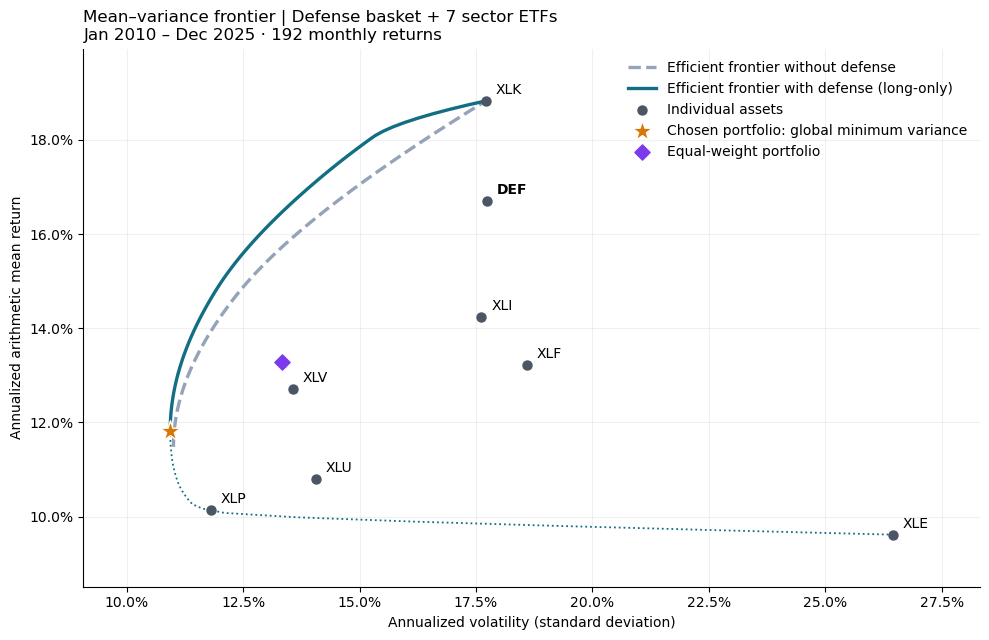

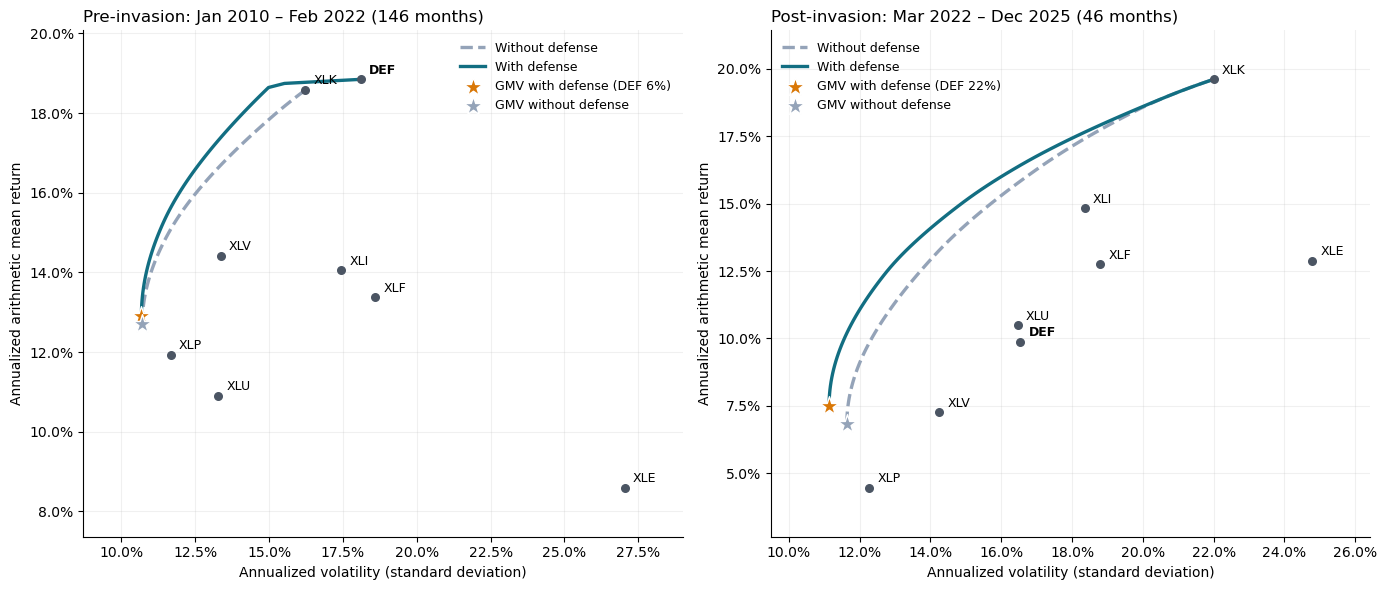

In [9]:
plt.rcParams.update({"font.size": 10, "axes.spines.top": False, "axes.spines.right": False})
COLORS = {"with": "#126E82", "without": "#94A3B8", "gmv": "#D97706", "assets": "#4B5563", "eq": "#7C3AED"}

def draw_frontier(ax, res, color, label, style="-", lower_branch=True):
    f = res["frontier"]
    eff = f[f["Efficient"]]
    ax.plot(eff["StdDev"], eff["Return"], style, color=color, lw=2.4, label=label)
    if lower_branch:
        gmv_return = res["gmv"] @ res["m"]
        low = f[f["Return"] <= gmv_return + 1e-9]
        if len(low) > 1:
            ax.plot(low["StdDev"], low["Return"], ":", color=color, lw=1.3)

def format_axes(ax, title):
    ax.xaxis.set_major_formatter(PercentFormatter(1))
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.set_xlabel("Annualized volatility (standard deviation)")
    ax.set_ylabel("Annualized arithmetic mean return")
    ax.set_title(title, loc="left")
    ax.grid(alpha=.18)
    ax.margins(x=.12, y=.12)

# Figure 1: full-sample frontier with the chosen portfolio
fig, ax = plt.subplots(figsize=(10, 6.5))
full_r = periods["Full sample"]
draw_frontier(ax, results[("Full sample", "Without defense")], COLORS["without"], "Efficient frontier without defense", style="--", lower_branch=False)
draw_frontier(ax, chosen, COLORS["with"], "Efficient frontier with defense (long-only)")
mu_full, cov_full = estimate(full_r)
std_full = np.sqrt(np.diag(cov_full))
ax.scatter(std_full, mu_full, color=COLORS["assets"], s=42, zorder=5, label="Individual assets")
for i, t in enumerate(full_r.columns):
    ax.annotate(t, (std_full[i], mu_full[t]), xytext=(7, 5), textcoords="offset points", weight="bold" if t == DEFENSE_LABEL else "normal")
gmv_w = chosen["gmv"]
ax.scatter(np.sqrt(gmv_w @ chosen["C"] @ gmv_w), gmv_w @ chosen["m"], marker="*", s=240, color=COLORS["gmv"], edgecolor="white", zorder=6, label="Chosen portfolio: global minimum variance")
eq_w = np.ones(len(full_r.columns)) / len(full_r.columns)
ax.scatter(np.sqrt(eq_w @ chosen["C"] @ eq_w), eq_w @ chosen["m"], marker="D", s=60, color=COLORS["eq"], zorder=6, label="Equal-weight portfolio")
format_axes(ax, f"Mean–variance frontier | Defense basket + 7 sector ETFs\n{full_r.index.min().strftime("%b %Y")} – {full_r.index.max().strftime("%b %Y")} · {len(full_r)} monthly returns")
ax.legend(loc="best", frameon=False)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "frontier_full_sample.png", dpi=200)
fig.savefig(OUTPUT_DIR / "frontier_full_sample.pdf")
plt.show()

# Figure 2: pre- vs post-invasion, with and without defense
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)
for ax, period_name in zip(axes, ["Pre-invasion", "Post-invasion"]):
    r = periods[period_name]
    draw_frontier(ax, results[(period_name, "Without defense")], COLORS["without"], "Without defense", style="--", lower_branch=False)
    draw_frontier(ax, results[(period_name, "With defense")], COLORS["with"], "With defense", lower_branch=False)
    for universe_name, color in [("With defense", COLORS["gmv"]), ("Without defense", COLORS["without"])]:
        res = results[(period_name, universe_name)]
        w = res["gmv"]
        ax.scatter(np.sqrt(w @ res["C"] @ w), w @ res["m"], marker="*", s=200, color=color, edgecolor="white", zorder=6,
                   label=f"GMV {universe_name.lower()}" + (f" (DEF {w[0]:.0%})" if universe_name == "With defense" else ""))
    mu_p, cov_p = estimate(r)
    std_p = np.sqrt(np.diag(cov_p))
    ax.scatter(std_p, mu_p, color=COLORS["assets"], s=30, zorder=5)
    for i, t in enumerate(r.columns):
        ax.annotate(t, (std_p[i], mu_p[t]), xytext=(6, 4), textcoords="offset points", fontsize=9, weight="bold" if t == DEFENSE_LABEL else "normal")
    format_axes(ax, f"{period_name}: {r.index.min().strftime("%b %Y")} – {r.index.max().strftime("%b %Y")} ({len(r)} months)")
    ax.legend(loc="best", frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "frontier_pre_post_invasion.png", dpi=200)
fig.savefig(OUTPUT_DIR / "frontier_pre_post_invasion.pdf")
plt.show()

## 9. Export full-precision results

All tables are written to one workbook, `analysis_results.xlsx`, with one sheet per table. Numeric returns and weights are stored as decimals (0.10 = 10%) and formatted as percentages. Months are written as `YYYY-MM`.

In [10]:
def month_index_to_text(table):
    table = table.copy()
    if isinstance(table.index, pd.PeriodIndex):
        table.index = table.index.astype(str)
    for column in table.columns:
        if isinstance(table[column].dtype, pd.PeriodDtype):
            table[column] = table[column].astype(str)
    return table

tables = {"asset_metrics_full": summaries["Full sample"], "asset_metrics_pre": summaries["Pre-invasion"], "asset_metrics_post": summaries["Post-invasion"],
          "correlation_full": correlations["Full sample"], "defense_correlations": defense_corr,
          "annual_covariance_full": estimate(periods["Full sample"])[1],
          "portfolios": portfolios.reset_index(), "exclusion_cost": exclusion_cost, "defense_weight_sensitivity": sensitivity,
          "bootstrap_gmv_defense": bootstrap_summary, "monthly_returns": returns,
          "frontier_full_with_def": chosen["frontier"], "data_audit": audit, "security_history": identity, "periods": period_table}
no_index = {"portfolios", "frontier_full_with_def", "security_history"}
percent_sheets = {"asset_metrics_full", "asset_metrics_pre", "asset_metrics_post", "portfolios", "exclusion_cost",
                  "defense_weight_sensitivity", "monthly_returns", "frontier_full_with_def"}
with pd.ExcelWriter(OUTPUT_DIR / "analysis_results.xlsx", engine="openpyxl") as writer:
    for name, table in tables.items():
        table = month_index_to_text(table)
        table.to_excel(writer, sheet_name=name[:31], index=name not in no_index)
        sheet = writer.sheets[name[:31]]
        sheet.freeze_panes = "B2"
        for column in sheet.columns:
            sheet.column_dimensions[column[0].column_letter].width = min(35, max(12, len(str(column[0].value or "")) + 3))
        if name in percent_sheets:
            for row in sheet.iter_rows(min_row=2):
                for cell in row:
                    header = sheet.cell(1, cell.column).value
                    if isinstance(cell.value, float) and header not in {"Months"}:
                        cell.number_format = "0.00%"
print(f"Results saved in {OUTPUT_DIR.resolve()}")

Results saved in /Users/kam/Desktop/CFM301 Project 1/CFM301/Project 1/defense_results
